# 06_Portfolio_Digital_Twin

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/lending_optimized_dataset.csv")

df.head()

,Agmt Id,Cust Age,Cust Gender,Cust Cibil Score,Cust Employment Type,Cust Net Salary,Coborrower Flag,App Score Risk,Agmt Date,Seizure Date,...,Residual_Loss,Residual_Risk_Score,Risk_Band,Profitability_Score,Recommended_LTV,Recommended_Tenure,Expected_Profit,PD,Expected_Loss,Interest_Income
0,ASSET_1,29,F,-1,NREGI,30000,N,LOW RISK,2023-12-27,2025-05-23,...,49938.752492,61.652781,High,49.149826,65,36,34221.597151,0.18,6777.135449,40998.732600
1,ASSET_2,24,M,-1,NREGI,60000,N,LOW RISK,2025-11-20,2026-05-31,...,57607.499292,53.939606,Low,61.601845,85,60,45542.462521,0.03,1246.724979,46789.187500
2,ASSET_3,32,F,763,AGR,29500,N,LOW RISK,2024-05-16,2025-06-24,...,45634.794337,56.583750,Medium,61.875776,75,48,35354.835736,0.08,3092.063547,38446.899283
3,ASSET_4,25,F,-1,NREGI,40000,N,MEDIUM RISK,2025-10-24,2026-04-30,...,43745.594480,53.024963,Low,51.458620,85,60,32139.783499,0.03,962.567834,33102.351333
4,ASSET_5,59,F,653,SAL,45000,N,MEDIUM RISK,2024-09-20,2025-05-30,...,41682.281346,50.523977,Low,89.466852,85,60,45236.310076,0.03,951.008440,46187.318517


In [3]:
portfolio_value = df["Loan Amount"].sum()

portfolio_profit = df["Expected_Profit"].sum()

avg_ltv = df["Recommended_LTV"].mean()

print("Portfolio Value:", round(portfolio_value))
print("Portfolio Profit:", round(portfolio_profit))
print("Average LTV:", round(avg_ltv,2))

Portfolio Value: 1472867646
Portfolio Profit: 928018013
Average LTV: 68.75


In [4]:
baseline = {
    "Portfolio_Value": portfolio_value,
    "Portfolio_Profit": portfolio_profit,
    "Average_LTV": avg_ltv
}

baseline

{'Portfolio_Value': np.int64(1472867646),
 'Portfolio_Profit': np.float64(928018013.31123),
 'Average_LTV': np.float64(68.75)}

In [5]:
ev_shock = df.copy()

ev_shock["Residual_Value_Forecast"] = (
    ev_shock["Residual_Value_Forecast"] * 0.90
)

In [6]:
ev_shock["Expected_Loss"] = (
    ev_shock["PD"] *
    (
        ev_shock["Loan Amount"]
        -
        ev_shock["Residual_Value_Forecast"]
    )
)

ev_shock["Expected_Profit"] = (
    ev_shock["Interest_Income"]
    -
    ev_shock["Expected_Loss"]
)

In [7]:
comparison = pd.DataFrame({

    "Metric":[
        "Profit",
        "Residual Value"
    ],

    "Baseline":[

        df["Expected_Profit"].sum(),

        df["Residual_Value_Forecast"].sum()
    ],

    "EV_Shock":[

        ev_shock["Expected_Profit"].sum(),

        ev_shock["Residual_Value_Forecast"].sum()
    ]
})

comparison

,Metric,Baseline,EV_Shock
0,Profit,9.280180e+08,9.188222e+08
1,Residual Value,6.710350e+08,6.039315e+08


In [8]:
inflation = df.copy()

inflation["Residual_Value_Forecast"] *= 0.95

inflation["Expected_Loss"] = (

    inflation["PD"] *
    (
        inflation["Loan Amount"]
        -
        inflation["Residual_Value_Forecast"]
    )
)

inflation["Expected_Profit"] = (

    inflation["Interest_Income"]
    -
    inflation["Expected_Loss"]
)

In [9]:
scenario_results = pd.DataFrame({

    "Scenario":[
        "Baseline",
        "EV Shock",
        "Inflation Shock"
    ],

    "Portfolio_Profit":[

        df["Expected_Profit"].sum(),

        ev_shock["Expected_Profit"].sum(),

        inflation["Expected_Profit"].sum()
    ]
})

scenario_results

,Scenario,Portfolio_Profit
0,Baseline,9.280180e+08
1,EV Shock,9.188222e+08
2,Inflation Shock,9.234201e+08


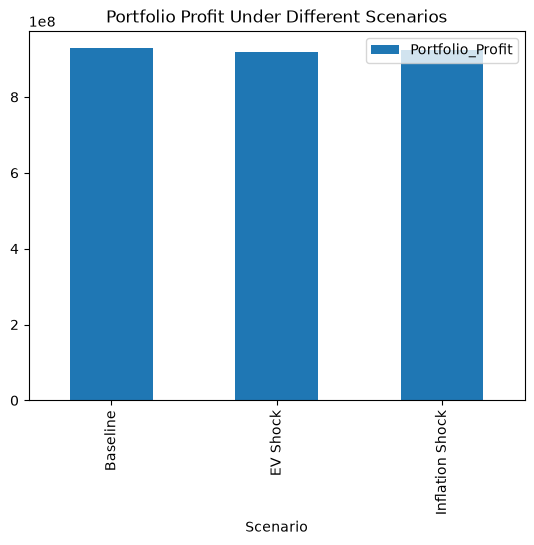

In [10]:
import matplotlib.pyplot as plt

scenario_results.plot(
    x="Scenario",
    y="Portfolio_Profit",
    kind="bar"
)

plt.title("Portfolio Profit Under Different Scenarios")

plt.show()

In [ ]:
scenario_results.to_csv(
    "../data/processed/scenario_results.csv",
    index=False
)

print("Portfolio Digital Twin complete")

We created a Portfolio Digital Twin. TVS can simulate EV disruption, inflation, or market shocks and instantly see portfolio profitability impact before making lending decisions